In [109]:
## Get needed functions
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from numpy import float32
import torch 
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset
import torch.nn as nn
from torch.utils.data import random_split

In [110]:
## Import created functions
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))



from src.train import train
from src.evaluate import evaluate

In previous notebook we downloaded data and converted to tensors. Here we will load the processed data, pass it to the dataloader and train it. 

In [111]:
## Load the data
data = torch.load("../data/processed_data.pt")

X_tensor = data["X"]
y_tensor = data["y"]
class_names = data['class_names']


I created a dataset class 
split the data and transform it into tensors, and run through the whole pipeline. I am going to use train_test_split from scikit because it lets me stratify the split by Cell type names.

In [112]:


from src.dataset import SingleCellDataset
from torch.utils.data import DataLoader
## Here we have designed a Dataset object for my dataset. 

## Define dataset
dataset = SingleCellDataset(X_tensor, y_tensor)

## Split into train, validation, and test using train_test_split stratifying on cell types. 
## Ensure split is same always same by setting the random state

indices = list(range(len(dataset)))
labels = y_tensor.numpy()

train_idx, temporary_idx = train_test_split(
    indices,
    test_size=0.30,
    random_state=42,
    stratify=labels)

validate_idx, test_idx = train_test_split(
    temporary_idx,
    test_size=0.50,
    random_state=42,
    stratify=labels[temporary_idx])

train_dataset = Subset(dataset, train_idx)
validate_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)


## Now we get the train/validate/test dataloaders

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
validate_dataloader = DataLoader(validate_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)


## Save idxes to recreate dataset later
torch.save({"train_idx": train_idx,
        "validate_idx": validate_idx,
        "test_idx": test_idx,
    }, "../data/data_split.pt")

Ok now we have out data. I defined a 2 hidden state model. Let's see what its baseline accuracy is before we tune it. I have a helper function set_seed to ensure consistency. I also defined an evalution function that prints the accruacy and the average loss. 

In [ ]:
from src.model import SingleCellModel
from src.train import train
from src.evaluate import evaluate
from src.utils import set_seed
set_seed(42)


baseline_model = SingleCellModel(
    num_features=X_tensor.shape[1],
    num_classes=len(class_names),
    hidden_size1=256,
    hidden_size2=64,
    dropout_rate=0.3,
)

train(
    train_dataloader,
    baseline_model,
    num_epochs=50,
    lr=0.001,
    weight_decay=0,
)

baseline_accuracy, baseline_loss = evaluate(
    test_dataloader,
    baseline_model,
)

print(
    f"Baseline accuracy: {baseline_accuracy:.4f} | "
    f"Baseline loss: {baseline_loss:.4f}"
)
## Baseline accuracy: 0.8286 | Baseline loss: 0.8575

Epoch 1/50 complete. Loss: 1.2786
Epoch 2/50 complete. Loss: 0.0568
Epoch 3/50 complete. Loss: 0.0618
Epoch 4/50 complete. Loss: 0.0115
Epoch 5/50 complete. Loss: 0.0070
Epoch 6/50 complete. Loss: 0.0130
Epoch 7/50 complete. Loss: 0.0075
Epoch 8/50 complete. Loss: 0.0027
Epoch 9/50 complete. Loss: 0.0021
Epoch 10/50 complete. Loss: 0.0015
Epoch 11/50 complete. Loss: 0.0010
Epoch 12/50 complete. Loss: 0.0003
Epoch 13/50 complete. Loss: 0.0006
Epoch 14/50 complete. Loss: 0.0005
Epoch 15/50 complete. Loss: 0.0002
Epoch 16/50 complete. Loss: 0.0011
Epoch 17/50 complete. Loss: 0.0005
Epoch 18/50 complete. Loss: 0.0003
Epoch 19/50 complete. Loss: 0.0018
Epoch 20/50 complete. Loss: 0.0018
Epoch 21/50 complete. Loss: 0.0005
Epoch 22/50 complete. Loss: 0.0001
Epoch 23/50 complete. Loss: 0.0002
Epoch 24/50 complete. Loss: 0.0003
Epoch 25/50 complete. Loss: 0.0002
Epoch 26/50 complete. Loss: 0.0004
Epoch 27/50 complete. Loss: 0.0004
Epoch 28/50 complete. Loss: 0.0003
Epoch 29/50 complete. Loss: 0

Baseline accuracy: 0.8286 | Baseline loss: 0.8575

Ok lets see if we can improve this at all. I wrote a tune function that uses optuna to try a variety of hyperparameters. 

In [ ]:
import optuna 
from src.optuna import tune

set_seed(42)
study = tune(
    X_tensor, class_names , train_dataloader, 
    validate_dataloader, num_epochs = 50, num_trials = 100)

[I 2026-07-30 09:24:29,973] A new study created in memory with name: no-name-087026d5-286d-4ccf-9664-590dc8cc04ac


Epoch 1/50 complete. Loss: 0.8633
Epoch 2/50 complete. Loss: 0.0077
Epoch 3/50 complete. Loss: 0.0159
Epoch 4/50 complete. Loss: 0.0066
Epoch 5/50 complete. Loss: 0.0023
Epoch 6/50 complete. Loss: 0.0031
Epoch 7/50 complete. Loss: 0.0039
Epoch 8/50 complete. Loss: 0.0021
Epoch 9/50 complete. Loss: 0.0021
Epoch 10/50 complete. Loss: 0.0014
Epoch 11/50 complete. Loss: 0.0008
Epoch 12/50 complete. Loss: 0.0006
Epoch 13/50 complete. Loss: 0.0005
Epoch 14/50 complete. Loss: 0.0008
Epoch 15/50 complete. Loss: 0.0006
Epoch 16/50 complete. Loss: 0.0015
Epoch 17/50 complete. Loss: 0.0005
Epoch 18/50 complete. Loss: 0.0004
Epoch 19/50 complete. Loss: 0.0028
Epoch 20/50 complete. Loss: 0.0019
Epoch 21/50 complete. Loss: 0.0010
Epoch 22/50 complete. Loss: 0.0005
Epoch 23/50 complete. Loss: 0.0008
Epoch 24/50 complete. Loss: 0.0013
Epoch 25/50 complete. Loss: 0.0013
Epoch 26/50 complete. Loss: 0.0020
Epoch 27/50 complete. Loss: 0.0028
Epoch 28/50 complete. Loss: 0.0017
Epoch 29/50 complete. Loss: 0

[I 2026-07-30 09:24:31,266] Trial 0 finished with value: 0.45184148900388255 and parameters: {'lr': 0.001720091147635508, 'weight_decay': 0.000598692197903775, 'hidden_size1': 256, 'hidden_size2': 64, 'dropout_rate': 0.11352969928134501}. Best is trial 0 with value: 0.45184148900388255.


Epoch 43/50 complete. Loss: 0.0011
Epoch 44/50 complete. Loss: 0.0011
Epoch 45/50 complete. Loss: 0.0022
Epoch 46/50 complete. Loss: 0.0006
Epoch 47/50 complete. Loss: 0.0034
Epoch 48/50 complete. Loss: 0.0007
Epoch 49/50 complete. Loss: 0.0010
Epoch 50/50 complete. Loss: 0.0014
Epoch 1/50 complete. Loss: 0.9171
Epoch 2/50 complete. Loss: 0.6960
Epoch 3/50 complete. Loss: 0.2510
Epoch 4/50 complete. Loss: 0.0895
Epoch 5/50 complete. Loss: 0.1590
Epoch 6/50 complete. Loss: 0.0933
Epoch 7/50 complete. Loss: 0.0331
Epoch 8/50 complete. Loss: 0.0176
Epoch 9/50 complete. Loss: 0.0415
Epoch 10/50 complete. Loss: 0.0367
Epoch 11/50 complete. Loss: 0.0108
Epoch 12/50 complete. Loss: 0.0305
Epoch 13/50 complete. Loss: 0.0254
Epoch 14/50 complete. Loss: 0.0354
Epoch 15/50 complete. Loss: 0.0266
Epoch 16/50 complete. Loss: 0.0386
Epoch 17/50 complete. Loss: 0.0337
Epoch 18/50 complete. Loss: 0.0599
Epoch 19/50 complete. Loss: 0.0283
Epoch 20/50 complete. Loss: 0.0387
Epoch 21/50 complete. Loss: 0

[I 2026-07-30 09:24:32,507] Trial 1 finished with value: 0.4173898095176333 and parameters: {'lr': 0.0006612187729800579, 'weight_decay': 0.008211333236924733, 'hidden_size1': 256, 'hidden_size2': 32, 'dropout_rate': 0.18452389039204567}. Best is trial 1 with value: 0.4173898095176333.


...

Epoch 47/50 complete. Loss: 0.0689
Epoch 48/50 complete. Loss: 0.1575
Epoch 49/50 complete. Loss: 0.1756
Epoch 50/50 complete. Loss: 0.1071
Epoch 1/50 complete. Loss: 1.2387
Epoch 2/50 complete. Loss: 0.5875
Epoch 3/50 complete. Loss: 0.0625
Epoch 4/50 complete. Loss: 0.0093
Epoch 5/50 complete. Loss: 0.0018
Epoch 6/50 complete. Loss: 0.0055
Epoch 7/50 complete. Loss: 0.0011
Epoch 8/50 complete. Loss: 0.0041
Epoch 9/50 complete. Loss: 0.0024
Epoch 10/50 complete. Loss: 0.0019
Epoch 11/50 complete. Loss: 0.0014
Epoch 12/50 complete. Loss: 0.0012
Epoch 13/50 complete. Loss: 0.0008
Epoch 14/50 complete. Loss: 0.0011
Epoch 15/50 complete. Loss: 0.0004
Epoch 16/50 complete. Loss: 0.0010
Epoch 17/50 complete. Loss: 0.0009
Epoch 18/50 complete. Loss: 0.0003
Epoch 19/50 complete. Loss: 0.0004
Epoch 20/50 complete. Loss: 0.0042
Epoch 21/50 complete. Loss: 0.0003
Epoch 22/50 complete. Loss: 0.0010
Epoch 23/50 complete. Loss: 0.0007
Epoch 24/50 complete. Loss: 0.0003
Epoch 25/50 complete. Loss: 0

[I 2026-07-30 09:26:26,733] Trial 98 finished with value: 0.521486991360074 and parameters: {'lr': 0.0021944146086661973, 'weight_decay': 0.00032032850546579155, 'hidden_size1': 128, 'hidden_size2': 32, 'dropout_rate': 0.182728639276984}. Best is trial 64 with value: 0.35027396849223547.


Epoch 44/50 complete. Loss: 0.0004
Epoch 45/50 complete. Loss: 0.0012
Epoch 46/50 complete. Loss: 0.0002
Epoch 47/50 complete. Loss: 0.0003
Epoch 48/50 complete. Loss: 0.0009
Epoch 49/50 complete. Loss: 0.0016
Epoch 50/50 complete. Loss: 0.0001
Epoch 1/50 complete. Loss: 2.2360
Epoch 2/50 complete. Loss: 2.1137
Epoch 3/50 complete. Loss: 2.0848
Epoch 4/50 complete. Loss: 2.0839
Epoch 5/50 complete. Loss: 1.7820
Epoch 6/50 complete. Loss: 1.4761
Epoch 7/50 complete. Loss: 1.7128
Epoch 8/50 complete. Loss: 1.3063
Epoch 9/50 complete. Loss: 1.4109
Epoch 10/50 complete. Loss: 0.7821
Epoch 11/50 complete. Loss: 1.0821
Epoch 12/50 complete. Loss: 0.9340
Epoch 13/50 complete. Loss: 0.7287
Epoch 14/50 complete. Loss: 1.1181
Epoch 15/50 complete. Loss: 0.5171
Epoch 16/50 complete. Loss: 0.4181
Epoch 17/50 complete. Loss: 0.7565
Epoch 18/50 complete. Loss: 0.5380
Epoch 19/50 complete. Loss: 0.2703
Epoch 20/50 complete. Loss: 0.6217
Epoch 21/50 complete. Loss: 0.6076
Epoch 22/50 complete. Loss: 0

[I 2026-07-30 09:26:28,019] Trial 99 finished with value: 0.37502438397634597 and parameters: {'lr': 5.7032300436081306e-05, 'weight_decay': 0.00011431640059790777, 'hidden_size1': 128, 'hidden_size2': 64, 'dropout_rate': 0.13539695543034902}. Best is trial 64 with value: 0.35027396849223547.


Epoch 44/50 complete. Loss: 0.0257
Epoch 45/50 complete. Loss: 0.0694
Epoch 46/50 complete. Loss: 0.0807
Epoch 47/50 complete. Loss: 0.0328
Epoch 48/50 complete. Loss: 0.0738
Epoch 49/50 complete. Loss: 0.0926
Epoch 50/50 complete. Loss: 0.0467


Below are the best hyperparameters and validation loss. Considerably better than the baseline function. 

In [ ]:
print("Best validation loss:", study.best_value)
print("Best hyperparameters:", study.best_params)
best_params = study.best_params
torch.save({"best_params": study.best_params, "num_features": X_tensor.shape[1], "num_classes": len(class_names)}, 
"../data/model_info.pt")


Best validation loss: 0.35027396849223547
Best hyperparameters: {'lr': 8.587755532173362e-05, 'weight_decay': 5.280750692285469e-06, 'hidden_size1': 128, 'hidden_size2': 64, 'dropout_rate': 0.10014135274998023}


I rewrote my train function to give training loss for both the training set and the valuation step for diagnostic purposes.

Epoch 1/100 complete. Train loss: 2.2122 Validation loss: 2.1543
Epoch 2/100 complete. Train loss: 2.0898 Validation loss: 2.0446
Epoch 3/100 complete. Train loss: 1.9440 Validation loss: 1.8899
Epoch 4/100 complete. Train loss: 1.7489 Validation loss: 1.6868
Epoch 5/100 complete. Train loss: 1.5134 Validation loss: 1.4470
Epoch 6/100 complete. Train loss: 1.2676 Validation loss: 1.2185
Epoch 7/100 complete. Train loss: 1.0697 Validation loss: 1.0484
Epoch 8/100 complete. Train loss: 0.9283 Validation loss: 0.9298
Epoch 9/100 complete. Train loss: 0.8289 Validation loss: 0.8469
Epoch 10/100 complete. Train loss: 0.7476 Validation loss: 0.7855
Epoch 11/100 complete. Train loss: 0.6731 Validation loss: 0.7332
Epoch 12/100 complete. Train loss: 0.6104 Validation loss: 0.6876
Epoch 13/100 complete. Train loss: 0.5582 Validation loss: 0.6492
Epoch 14/100 complete. Train loss: 0.5054 Validation loss: 0.6150
Epoch 15/100 complete. Train loss: 0.4559 Validation loss: 0.5847
Epoch 16/100 comple

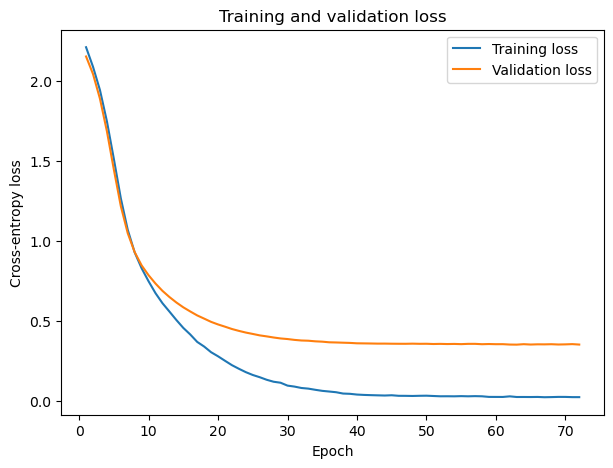

In [127]:
set_seed(42)
diagnostic_model = SingleCellModel(
    num_features=X_tensor.shape[1],
    num_classes=len(class_names),
    hidden_size1=best_params["hidden_size1"],
    hidden_size2=best_params["hidden_size2"],
    dropout_rate=best_params["dropout_rate"],
)



## Train diagnostic model
diagnostic_model, history = train(
    dataloader=train_dataloader,
    model=diagnostic_model,
    num_epochs=100,
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"],
    validation_dataloader=validate_dataloader,
    patience=10,
    min_delta=0.001) 

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs, history["train_loss"], label="Training loss")
plt.plot(epochs, history["validation_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training and validation loss")
plt.legend()
#plt.tight_layout()
plt.show()


Ok looks good. No overfitting or increase in validation loss. 50 may be a bit of an overkill. I added early stopping and it dies at 72. This means that with a patience of 10 that 50 was the last epoch that had no decrease in loss. 

Lets use these best parameters calculated above for our final validation model and train it on the combined validation and training dataset to increase final training data.

In [128]:
## Test model on test set
set_seed(42)

final_model = SingleCellModel(
    num_features=X_tensor.shape[1],
    num_classes=len(class_names),
    hidden_size1=best_params["hidden_size1"],
    hidden_size2=best_params["hidden_size2"],
    dropout_rate=best_params["dropout_rate"],
)

## Here to boost power for training final model we combine the train and the validate dataset. 

train_validation_dataset = ConcatDataset([
    train_dataloader.dataset,
    validate_dataloader.dataset])

final_train_dataloader = DataLoader(
    train_validation_dataset,
    batch_size=train_dataloader.batch_size,
    shuffle=True)


## Train final model
final_model, final_history = train(
    final_train_dataloader,
    final_model,
    num_epochs=72, # Number of epoch identified earlier
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"])


Epoch 1/72 complete. Train loss: 2.1979
Epoch 2/72 complete. Train loss: 2.0539
Epoch 3/72 complete. Train loss: 1.8574
Epoch 4/72 complete. Train loss: 1.5902
Epoch 5/72 complete. Train loss: 1.2949
Epoch 6/72 complete. Train loss: 1.0616
Epoch 7/72 complete. Train loss: 0.9030
Epoch 8/72 complete. Train loss: 0.7903
Epoch 9/72 complete. Train loss: 0.7059
Epoch 10/72 complete. Train loss: 0.6344
Epoch 11/72 complete. Train loss: 0.5708
Epoch 12/72 complete. Train loss: 0.5161
Epoch 13/72 complete. Train loss: 0.4683
Epoch 14/72 complete. Train loss: 0.4182
Epoch 15/72 complete. Train loss: 0.3729
Epoch 16/72 complete. Train loss: 0.3367
Epoch 17/72 complete. Train loss: 0.2995
Epoch 18/72 complete. Train loss: 0.2674
Epoch 19/72 complete. Train loss: 0.2398
Epoch 20/72 complete. Train loss: 0.2184
Epoch 21/72 complete. Train loss: 0.1949
Epoch 22/72 complete. Train loss: 0.1710
Epoch 23/72 complete. Train loss: 0.1547
Epoch 24/72 complete. Train loss: 0.1386
Epoch 25/72 complete. Tra

Now we save the final model weights to evaluate on the test dataset.

In [129]:
## Save the final model

torch.save(final_model.state_dict(), "../models/final_model.pt")